# Week 7: Principal Component Analysis using the SVD and scikit-learn with examples

In this week's notebook you'll import sample data sets from the package scikit-learn and see what PCA tells you about the data

principal Component Analysis is a way of ranking the directions along which a set of data varies. By keeping the directions of largest variation ("principal components") you can sometimes approximate data in a high-dimensional space using a lower dimensional data set.

Key ideas or skills for this week are:

1. You can regard a data set with $n$ observations and $k$ variables as an $n\times k$ matrix $X$. So each observation is a $k$-dimensional vector.
2. Be able to center the data the data by subtracting the mean of each column: you get a new matrix $Xcentered$.
````
Xmean = np.mean(X,axis=0)
Xcentered = X - Xmean
````

3. Transpose the centered data to form a matrix $M = Xcentered.T$
4. Now $M$ is a $k\times n$ matrix that takes each $n$-dimensional standard basis vector $e_j$ to one of your centered observations.
5. Perform the SVD: 
````
H,s,CT = la.svd(M)
````
Then each columns of $H$ is a principal component of your centered data. They are ranked in order of importance: $H[:,:0]$ is most important, $H[:,:0]$ is next.
6. To approximate a particular $k$-dimensional vector using the first $n$ principal components, use our orthogonal approximation, remembering to shift the mean. If you use the first $a$ principal components, then the formula is (with $h_j = H[:,:j]$):
$$
\begin{align*}
 vcentered & = v - Xmean\\
 vapprox &= Xmean + (h_0 @ vcentered) * h_0 + \ldots + (h_{a-1} @ vcentered) * h_{a-1}.
\end{align*}
$$
In matrix notation and in Python, you can use
````
Happrox = H[:,:a]
vcentered = v - Xmean
vapprox = Xmean + Happrox @ Happrox.T @ vcentered
````
7. Learn how to do all of these things using the Python package scikit-learn or sklearn. This is important because, in a very large example, you may want to avoid computing the full SVD, and just get the information for some of the largest singular values.


## Initialization cells

The imports are a little different this time: we're asking you to import some additional standard data packages: seaborn which provides data visualization using matplotlib, pandas that provides a lot of dataset tools built on numpy, and scikit-learn or sklearn that provides lots of machine learning tools and examples.

In [2]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

import pandas as pd

import seaborn as sns
from sklearn import datasets
from sklearn.decomposition import PCA


ModuleNotFoundError: No module named 'pandas'

## End of initiatlization cells

## Summary and PCA work on the "Iris data set"

### Loading some data and seeing what the loaded information contains

scikit-learn's datatsets component, imported above, includes a few datasets; you can see more at https://scikit-learn.org/stable/datasets.html. Here we'll load a data set of measurements of iris flowers. This data set contains four measurements (sepal length, sepal width, petal length, and petal width) about 150 iris plants. The plants are divided into three sub-categories (Iris Setosa, Iris Versicolour, and Iris Virginica).

In [2]:
# this command reads data from scikit-learn's library
iris = datasets.load_iris()
# This is the data type
print(type(iris))

<class 'sklearn.utils.Bunch'>


If you've got a mystery item, say x, you can find out about it by entering ?x and ??x (one question mark does something different from two). Try it here, for example:

In [ ]:
?iris

In [ ]:
??iris

From this you can see you can access pieces of the information stored in "iris" using "iris.itemname"  or "iris['itemname']".  From the ?? inquiry, you can see all the things you can ask for. For example, try the next line.

In [ ]:
print(iris.DESCR)

Here is a picture of three plants (one from each category).

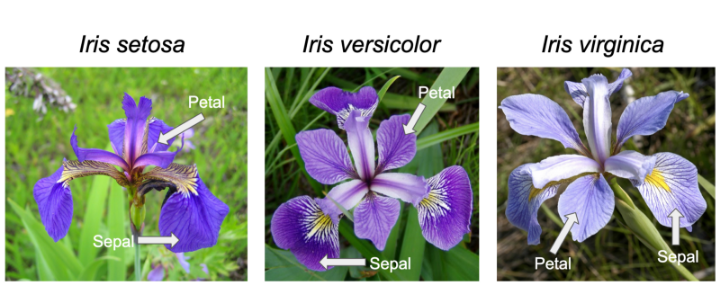

The dataset provides measurements of 4 features, whose names are in the list iris.feature_names.

In [3]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


The core data is measurements of these four features on 150 iris flowers. This gives a table of 150 rows and 4 columns of numbers, stored in iris.data. 

In [4]:
print(iris.data.shape)
print(iris.data)

(150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6

The 150 irises are the measurements for 50 examples of each of three types. The names of the three types are stored in iris.target_names.

In [ ]:
print(iris.target_names)

Each of the 150 rows of iris.data corresponds to one of the three types, and in the length 150 array iris.target, the j row tells you the type of the j row of iris.data.

In [5]:
print(iris.target.shape)
print(iris.target)

(150,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [6]:
X = iris.data
typelist = iris.target
print("Dimensions of X:",X.shape)
print("Dimensions of typelist:",typelist.shape)

Dimensions of X: (150, 4)
Dimensions of typelist: (150,)


Here type 0 corresponds to "setosa", type 1 corresponds to "versicolor", and type 2 to "virginica". Let's conform that there are 50 of each.

In [7]:
print(f"Number of samples in iris class zero ({iris.target_names[0]}): {(typelist==0).sum()}")
print(f"Number of samples in iris class one ({iris.target_names[1]}): {(typelist==1).sum()}")
print(f"Number of samples in iris class two ({iris.target_names[2]}): {(typelist==2).sum()}")

Number of samples in iris class zero (setosa): 50
Number of samples in iris class one (versicolor): 50
Number of samples in iris class two (virginica): 50


## Making a dataframe and using it with seaborn to get an initial look at the data

Now let's make a pandas dataframe to hold our data. Pandas dataframes are a very convenient way to hold and manipulate tabular data. Moreover, many python data analysis routines take dataframes as input. That's why we'll make a dataframe here.

In [8]:
df_iris = pd.DataFrame(iris.data,columns=iris['feature_names'])

Let's see what this contains.

In [ ]:
df_iris 

Let's add one more column that gives the type of the iris in each row.

In [9]:
# this creates a list 150 entries. The j entry on the list is the name of the flower type of 
# the j entry in the list typelist 

typenamelist = [iris.target_names[flowertype] for flowertype in typelist]
typenamelist

['setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',
 'versicolor',


In [10]:
# the assign method adds another column of data. Type out to see what we get

df_iris = df_iris.assign(iris_type=typenamelist)
df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


This nice routine from the seaborn package looks at all the data columns in your data frame pairwise. Since you have four "variables" in your data, it produces a four-by-four grid of plots. The "hue='iris_type'" parameter tells pairplot to assign colors to use 'iris_type' to separate the data into three types, and color (and in the case of the diagonal plots, count) them separately. 

Being able to uses sns.pairplot is one of the reasons we put the data in a dataframe.

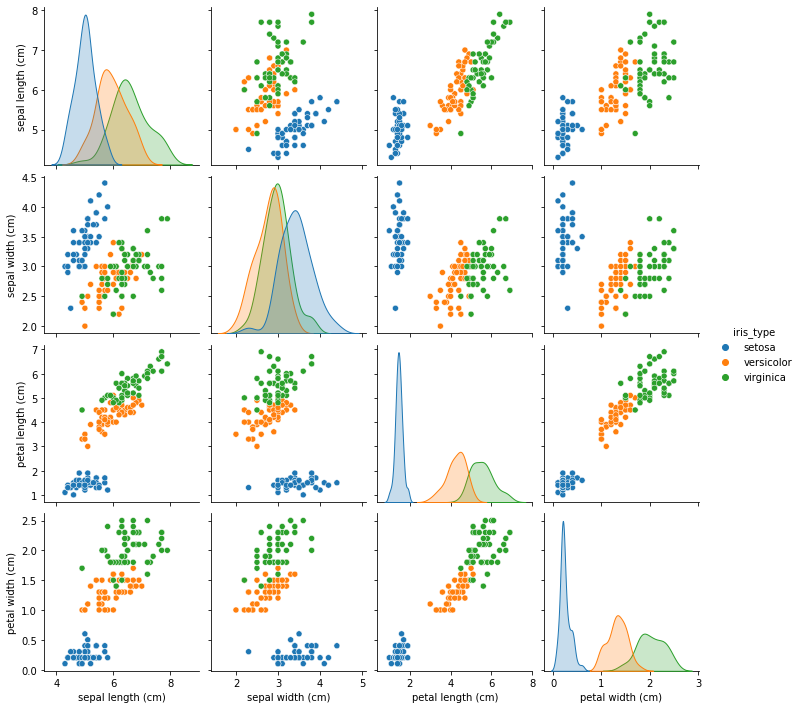

In [11]:
sns.pairplot(df_iris, hue='iris_type', palette="tab10")

# These optional commands make the plot a little bigger, and then it looks a little better
#fig = plt.gcf()
#fig.set_size_inches(20, 20)

Look at the plots above, and think about these questions or assertions:

1. Do the four measured features do a good job of distinguishing all three types of iris? Why or why not? 

2. Do the four measured features do a good job of separating "setosa" from "versicolor" and "virginica"? Why or why not? 

3. Do the four measured features do a good job of separating "versicolor" from "virginica"? Why or why not? 

4. Do you see any evidence that the four measured features have some redundancy? Explain.

5. Do you see any evidence that some of the four measured features are more or less effective than others at distinguishing the types of iris? Explain.

## Performing principal component analysis using the SVD

Let's try to use PCA to study these questions from another point of view and maybe find a way to distinguish these plants as best we can using the data we have. To do PCA using the SVD, we have to first center our data on zero. By that, I mean: for each of the four features measured, take the average measurement and subtract it from every entry, so that the average measurement is zero.  

Remember that our data has 150 rows and 4 columns; each row is a flower, and each column is a measured feature.

In [12]:
X.shape

(150, 4)

The numpy function "mean" takes the average of the entries of a numpy array. You can average the columns or the rows by specifying an axis. Here's an example.

In [ ]:
A = np.array([[1,11],[-1,9]])
print("Here is A:", A)
print("The mean of all entries of A:", np.mean(A))
print("The mean of the columns of A:", np.mean(A,axis=0))
print("The mean of the rows of A:",np.mean(A,axis=1))

In [13]:
# So here we'll take the mean of each column of the iris data
# You get one mean for each of the features you're measuring, so four means.

Xmean = np.mean(X,axis=0)
print(Xmean.shape)

(4,)


In [14]:
Xmean

array([5.84333333, 3.05733333, 3.758     , 1.19933333])

In [15]:
# Then we subract the mean from each row. In Xcentered, the mean of each column should be zero.
Xcentered = X - Xmean
print(Xcentered.shape)
print(np.around(np.mean(Xcentered,axis=0),decimals=3))

(150, 4)
[-0. -0. -0. -0.]


I like to use the tranpose of the data: in the transpose, each column corresponds to a flower. The $j$ column contains the four measurements (centered) for the $j$ flower. 

In [16]:
M = Xcentered.T
print(M.shape)

(4, 150)


If you think of the matrix $M=Xcentered^T$ as taking the $j$ unit coordinate vector in 150 dimensions to the four measurements of the $j$ flower, then $M$ takes 150 dimensions to four dimensions. It takes the unit sphere in 150 dimensions to an ellipsoid in four dimensions. What does the ellipsoid look like that we're getting in dimension $4$? Let's compute the SVD to find out.

In [17]:
H,s,CT = la.svd(M)

Let's look at the singular values:

In [18]:
print(s)

[25.09996044  6.01314738  3.41368064  1.88452351]


Since the first singular value is so much larger than the others, let's focus on the first two singular values and use them to present the iris data in a new way. First, let's look at the matrix $H$.

In [19]:
print(np.around(H,decimals=3))
print(H.shape)

# This is a way to test whether a matrix has orthonormal columns: Take its transpose, and comput H.T @ H.
# You get the identity matrix if and only if the matrix had orthonormal columns! 

print(np.around(H.T @ H,decimals=3))

[[-0.361 -0.657  0.582  0.315]
 [ 0.085 -0.73  -0.598 -0.32 ]
 [-0.857  0.173 -0.076 -0.48 ]
 [-0.358  0.075 -0.546  0.754]]
(4, 4)
[[ 1.  0. -0. -0.]
 [ 0.  1.  0.  0.]
 [-0.  0.  1.  0.]
 [-0.  0.  0.  1.]]


$H$ is four-by-four matrix with orhonormal columns. The $0$ column corresponds to the $0$ singular value and points in the direction of the longest axis of the ellipsoid. The $1$ column corresponds to the $1$ singular value, and points to in the direction of the next longest axis of the ellipsoid, and so forth. 

In our setting, we think of $\R^4$, the set of 4-vectors, measurements of a flower: each vector contains

$$
      [\text{sepia length}, \text{sepia width}, \text{petal length}, \text{petal width}]
$$      

The columns of $H$ are an orthonormal basis for $\R^{4}$, but they're a particularly good basis for measuring the irises, because $h_0 = H[:,:0]$ points in the direction of the greatest variation of our data, $h_1 = H[:,:1]$ points in the direction of next greatest variation, and so forth.

The $0$ column suggests to us that, instead of reporting sepia length, sepia width, petal length, and petal width, you may get more separation by looking at

$$
  -0.361 * \text{sepia length} + 0.085 * \text{sepia width} - 0.857 * \text{petal length} - 0.358 * \text{petal width};
$$
this is the dot product of the vector of measurements for the flower with the $0$ column of $H$.

The $1$ column suggests that, as our next measurement, we should look at

$$
  -0.657 * \text{sepia length} - 0.73 * \text{sepia width} + 0.173 * \text{petal length} + 0.075 * \text{petal width};
$$
this is the dot product of the vetor of measurements for the flower with the $1$ column of $H$.

Let's do that. For each of our 150 rows of Xcentered, we can take the dot product of the row, 
which in row $j$ is the centered verson of 

$$
      [\text{sepia length}, \text{sepia width}, \text{petal length}, \text{petal width}] \text{ for the $j$ flower},
$$      

with the $0$ and $1$ columns of $H$. We can do that by computing the matrix product

$$
Xcentered @ H!
$$

(In fact we just have to compute the first two columns of that matrix product)

In [ ]:
Xcentered.shape

The new matrix is:

In [20]:
Xtransformed = Xcentered @ H

Now let's make a plot like the ones above, but using the first two columns of Xtransformed as the measurements to represent each flower.

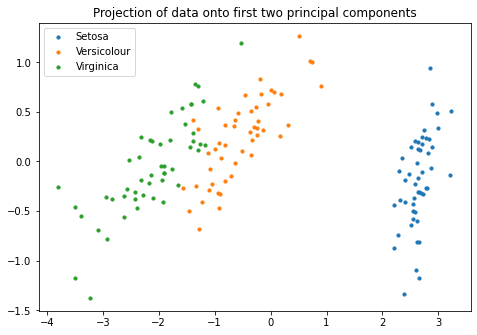

In [21]:
fig=plt.figure(figsize=[6.,4.])
ax=fig.add_axes([0, 0, 1, 1])

ax.set_title('Projection of data onto first two principal components')
for lbl,i in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.scatter(*Xtransformed.T[:2,typelist==i], label=lbl, s=10)

ax.legend()


## Performing PCA using scikit-learn

The package scikit-learn provides a way to get the same information with built-in tools. For small problems like this one, either method is OK. For large problems, sklearn gives you ways to reduce the memory demands of the computation. 

In [22]:
from sklearn.decomposition import PCA

# The PCA class is a class that holds a PCA computation
pca = PCA()

# Here we provide it with our data.  Two notes, given the work we had to do above:

# 1) No need to transpose: sklearn.decomposition.PCA expects the measurement types as columns, 
#    and the observations as rows.
#
# 2) No need to compute the mean and subtract it from each row: sklearn does this automatically

X_pca = pca.fit_transform(X)

In [23]:
X_pca.shape

(150, 4)

In [ ]:
Xtransformed.shape

Let's check that the canned PCA procedure gives the same result as our handicrafted approach using the SVD. First let's compare the singular values. Run the next cell to see all the things you can ask pca for.

In [ ]:
?pca

From doing this you can discover that you can access the singular values using pca.singular_values_. Let's check they match the ones we found using SVD.

In [24]:
print("Singular values from SVD: ",s)
print("Singular values from PCA procedure: ", pca.singular_values_)

Singular values from SVD:  [25.09996044  6.01314738  3.41368064  1.88452351]
Singular values from PCA procedure:  [25.09996044  6.01314738  3.41368064  1.88452351]


Scikit also gives you the mean of your data.

In [25]:
print(f"We computed the means of the each variable in our data set to be {Xmean}.")
print(f"scikit-learn says the mean is {pca.mean_}.")

We computed the means of the each variable in our data set to be [5.84333333 3.05733333 3.758      1.19933333].
scikit-learn says the mean is [5.84333333 3.05733333 3.758      1.19933333].


To get the columns of $H$, look at the "components".

In [26]:
print(f"The 0 column of H is {H[:,0]}.")
print(f"The 0 row of pca.components_ is {pca.components_[0]}.")

The 0 column of H is [-0.36138659  0.08452251 -0.85667061 -0.3582892 ].
The 0 row of pca.components_ is [ 0.36138659 -0.08452251  0.85667061  0.3582892 ].


Now comparing all columns of $H$ with all rows of `pca.compolents_`.

In [27]:
print(H)
print(pca.components_.T)

[[-0.36138659 -0.65658877  0.58202985  0.31548719]
 [ 0.08452251 -0.73016143 -0.59791083 -0.3197231 ]
 [-0.85667061  0.17337266 -0.07623608 -0.47983899]
 [-0.3582892   0.07548102 -0.54583143  0.75365743]]
[[ 0.36138659  0.65658877 -0.58202985 -0.31548719]
 [-0.08452251  0.73016143  0.59791083  0.3197231 ]
 [ 0.85667061 -0.17337266  0.07623608  0.47983899]
 [ 0.3582892  -0.07548102  0.54583143 -0.75365743]]


In these two matrices, each column is the same up to multiplication by plus or minus one. This is fine; it is an ambiguity in the SVD. Let's start with a matrix $M$ with SVD (and we'll use the trim SVD)

````
M = (H*s)@CT.
````
$M$ is an $n\times k$ matrix, and $d=\min(n,k)$.

Let's write out the columns of $H$
$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{d-1} \\
| & & |
\end{bmatrix},
$$
the rows of $CT$

$$
CT = \begin{bmatrix}
-- & c_0 & --\\
 & \vdots &  \\
-- & c_{d-1} & --\\
\end{bmatrix},
$$
and the singular values,
$$
s=[s_0,\ldots,s_{d-1}].
$$ 

The key points are: 
 
 1. $h_0,\ldots,h_{d-1}$ are orthonormal
 2. $c_0,\ldots,c_{d-1}$ are orthonormal 
 3. $Mc_j = s_j h_j$ 
 
 Notice that if I change $c_0$ to $-c_0$ and $h_0$ to $-h_0$, I still have two orthonormal sets, and I still have $M_(-c_0) = - M(c_0) = - s_0*  h_0 = s_0 * (-h_0).$
 
 Generally:
 
 >**Fact:** If $M=(H*s) @ CT$ is a singular value decomposition for $M$, then so is $(H'* s) @ CT'$, where $H'$ differs from $H$ by changing the sign of some columns, and $CT'$ differs from $CT$ by changing the signs of the *same* rows of $CT$. *The singular values do not change!*

The PCA class has additional methods that give you useful information about your PCA. 

In [28]:
print('Explained variance of each component of the PCA: ',pca.explained_variance_ratio_)

cumulative_variance_explained = np.cumsum(pca.explained_variance_ratio_)

for i in range(len(cumulative_variance_explained)):
    print(f"Using {i+1} components captures {100.*cumulative_variance_explained[i]:0.2f} of the total variation in the 4 measurements.")



Explained variance of each component of the PCA:  [0.92461872 0.05306648 0.01710261 0.00521218]
Using 1 components captures 92.46 of the total variation in the 4 measurements.
Using 2 components captures 97.77 of the total variation in the 4 measurements.
Using 3 components captures 99.48 of the total variation in the 4 measurements.
Using 4 components captures 100.00 of the total variation in the 4 measurements.


Let's use the output of the canned PCA to redo our plot of the transformed data. 

In [ ]:
fig=plt.figure(figsize=[6.,4.])
ax=fig.add_axes([0, 0, 1, 1])

ax.set_title('Projection of data onto first two principal components')
for lbl,i in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.scatter(*X_pca.T[:2,typelist==i], label=lbl, s=10)

ax.legend()


## A higher dimensional example

This example is from https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html. The top of the linked page gives this licensing information:

>The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by buying the book!

It's important to know about and follow the terms of these licences. 

From scikit-learn we'll import a much larger data set of digital images. This could take a while, and it may not work on all computers. 

In [30]:
# The min_faces_per_person tells sklearn to provide only the images of those people 
# who appear 60 or more times in the data base
faces = datasets.fetch_lfw_people(min_faces_per_person=60)

In [32]:
faces??

This is a large data set. Let's see how large.

In [33]:
#
# As you'll see, this is a large dataset: there are 1348 
print(faces.target_names)
print(faces.images.shape)


['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


So the dataset includes 1348 images, with each image being 62 by 47 pixels. Let's look at a few.

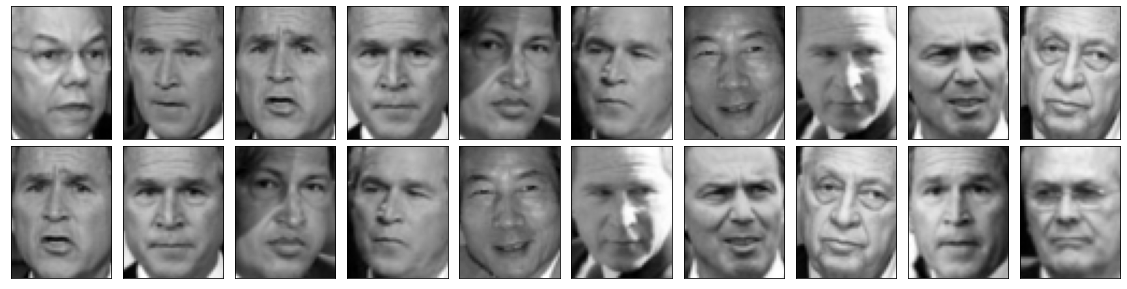

In [34]:
fig, ax = plt.subplots(2, 10, figsize=(20, 5),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.05, wspace=0.05))

for i in range(2):
    for j in range(10):
        ax[i,j].imshow(faces.images[2*i+j],cmap='binary_r')

As we've learned from previous work with images, it's useful to have the images saved as vector instead
of as a 2D numpy array. This dataset includes both: faces.images stores the images as rectangular arrays, and faces.data stores the images as 1D arrays. 

In [35]:

print(faces.images.shape)
print(faces.data.shape)

# check that the number of pixes in faces.data is the same as the number of pixels in faces.images

np.prod(faces.images.shape[1:])

(1348, 62, 47)
(1348, 2914)


2914

In [36]:
faces_mean = np.mean(faces.data,axis=0)
print(faces_mean.shape)
faces_centered = faces.data - faces_mean
print(faces_centered.shape)

(2914,)
(1348, 2914)


Let's quickly see how to display the images, using the centered data: you just back the mean and reshape.

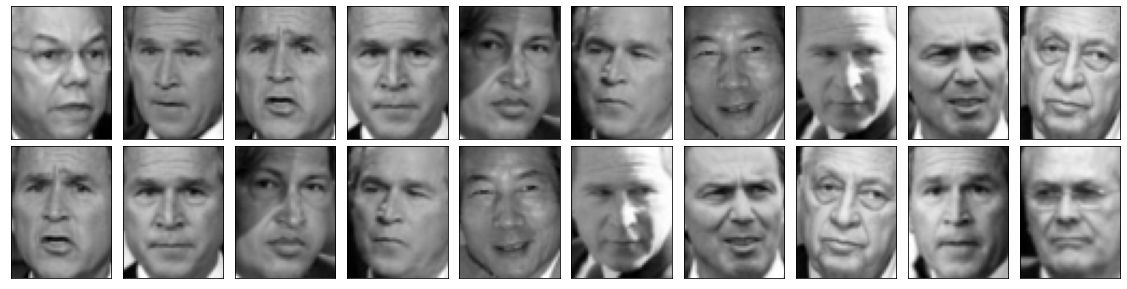

In [37]:
fig, ax = plt.subplots(2, 10, figsize=(20, 5),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.05, wspace=0.05))

for i in range(2):
    for j in range(10):
        ax[i,j].imshow((faces_centered[2*i+j]+faces_mean).reshape(62,47),cmap='binary_r')

Each image is a vector in 2,914-dimensional space. That's a big space! It is expensive to find all $1348$ singular values of the $1348\times 2914$ matrix `faces_centered`. This time, we'll use scikit-learn's PCA method, and only get the first 85 out of the total possible of 2,914 singular values. This uses much less memory and time.

In [38]:
## These two lines are lines you will need below in the Do-It.

pca = PCA(85)
transformed_data = pca.fit_transform(faces.data)

osize=faces.data.size
tsize=transformed_data.size
reducpct = np.around(100. * tsize/osize,decimals=1)
print(osize)
print(tsize)
print(f"The reduced data set takes up only {reducpct:0.1f}% of the space of the original data!")

3928072
114580
The reduced data set takes up only 2.9% of the space of the original data!


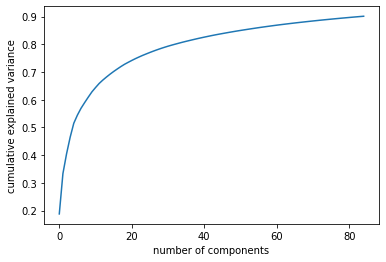

In [39]:
fig,ax=plt.subplots(1,1)
ax.plot(np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative explained variance');

The graph shows that by the time we look at the first 80 singular values, we're seeing about 90% of the variation in the photos.

What data do we have? We'll, let's look at the singular values and at `pca_components_`. Remember that the rows of  `pca_components_` are like the columns of our matrix $H$ in the SVD.

In [40]:
print(pca.singular_values_.shape)
print(pca.components_.shape)

(85,)
(85, 2914)


So, `pca.components_` has 85 rows and 2914 columns: each row is a vector associated to an image. Let's look at the first few.

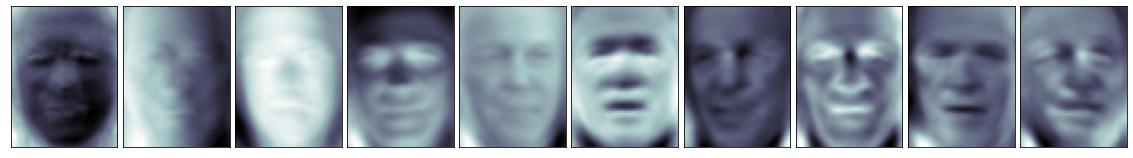

In [41]:
#fig, axes = plt.subplots(1, 6, figsize=(9, 4),
#                         subplot_kw={'xticks':[], 'yticks':[]},
#                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

fig, ax = plt.subplots(1, 10, figsize=(20, 5),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.05, wspace=0.05))

for i in range(10):
    ax[i].imshow(pca.components_[i].reshape(62, 47), cmap='bone')

These strange images are analogues of our images showing just a house or just a tree: they are orthonormal, and together they span a small 10-dimensional subspace of the $2914$-dimensional space of $2914$-pixel images. Let's check that they're orthonormal.

In [42]:
orthonormalcheck = [[pca.components_[i]@pca.components_[j] \
                     for i in range(10)] for j in range(10)]

np.allclose(orthonormalcheck, np.identity(10),atol=0.00001)

True

Now we can approximate any 2914-dimensional vector (so, an image) using our orthonormal frame! For example, let's try the $1$ image in our list of images.

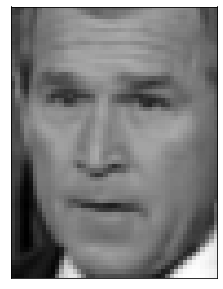

In [43]:
sample = faces.images[1]
sample_vec = faces.data[1]

fig, ax = plt.subplots(1,1, figsize=(20, 5),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.05, wspace=0.05))

ax.imshow(sample,cmap='binary_r')

Remember our formula? If $h_0,\ldots,h_{d-1}$ is an orthonormal frame in an $N$-dimensional space, and $v$ is any vector, then the closest vector to $v$ in the span of $h_0,\ldots,h_d$ is

$$
 P_H(v) = (h_0 @ v) * h_0 + \ldots (h_{d-1}@v) * h_{d-1}.
$$

It's very convenient to express this in terms of the matrix $H$ whose columns are the $h_j$:

$$
H = \begin{bmatrix}
| & & | \\
h_0 & \ldots  & h_{d-1} \\
| & & |
\end{bmatrix}.
$$

>**Fact:** 
$$
P_H(v) = H@ H.T @ v.
$$

Remember that our orthonormal frame was built from the centered images we got by subtracting the mean of each entry (pixel) of our samples.

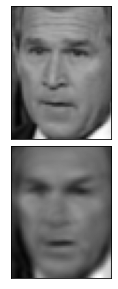

In [44]:
sample_centered_vec = sample_vec - faces_mean

Happrox = pca.components_.T

nvecs = 10


sample_approximated = Happrox @ Happrox.T @ sample_centered_vec

fig, ax = plt.subplots(2,1, figsize=(20, 5),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.05, wspace=0.05))

ax[0].imshow(sample,cmap='binary_r')
ax[1].imshow((sample_approximated+faces_mean).reshape(62,47),cmap='binary_r')

Actually, let's see this improve as we use an increasing number of singular values.

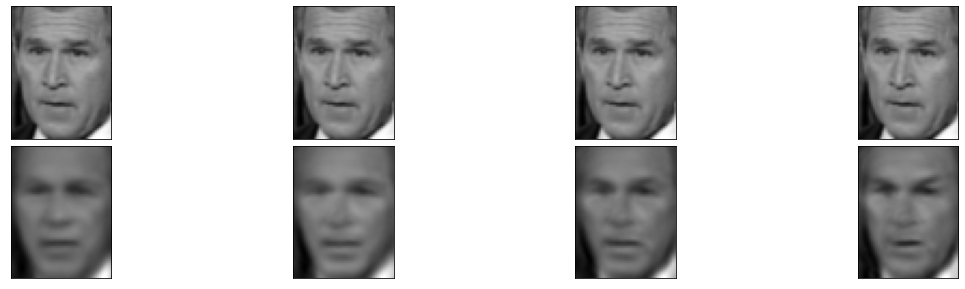

In [45]:
sample_centered_vec = sample_vec - faces_mean

Happrox = pca.components_.T

nsings = [20,40,60,85]

fig, ax = plt.subplots(2,4, figsize=(20, 5),
    subplot_kw={'xticks':[], 'yticks':[]},
    gridspec_kw=dict(hspace=0.05, wspace=0.05))


for i,n in enumerate(nsings):
    approximation = Happrox[:,:n] @ (Happrox[:,:n]).T @ sample_centered_vec
    ax[0,i].imshow(sample,cmap='binary_r')
    ax[1,i].imshow((approximation+faces_mean).reshape(62,47),cmap='binary_r')

So, to use PCA to approximate an vector using some sample data, here's what you do, using the SVD. 


1. Start with a data matrix $X$, with each column a "variable" or measurement type, and each row an obseration. Let's say that your matrix $X$ has $k$ columns; you are measuring $k$ things.
2. Replace the data matrix with one centered on zero: set 
````
Xmean = np.mean(X,axis=0)
Xcentered = X - Xmean
````
3. Compute the SVD of $Xcentered.T$: 
````
H,s,CT = la.SVD(Xcentered.T)
````
**IMPORTANT:** In practice, for a large data set, you may want to use scikit-learn's PCA package, and just get the first few largest singular values and the first few corresponding columns of $H$! 

4. Choose a number of singular values, say $150$. This depends on your situation.
5. Use $H$ to make a new matrix $Happrox$ using only the first 150 columns from $H$. Each column still has $k$ entries: $Happrox$ is a $k \times 150$ matrix.
````
Happrox = H[:,:150]
````
5. Suppose you want to approximate $v$. First you have to subtract the mean:
````
vcentered = v - Xmean
````

The approximation to `v` is
````
vapprox = Xmean + Happrox @ Happrox.T @ vcentered 
````

Scikit's pca method `inverse_transform` performs this approximation on all the original data you supplied to it.

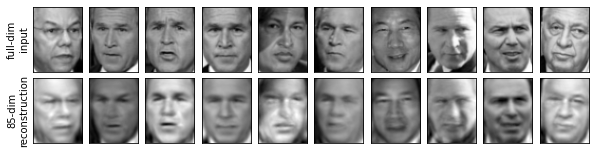

In [46]:
projected = pca.inverse_transform(transformed_data)

# Plot the results
fig, ax = plt.subplots(2, 10, figsize=(10, 2.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i in range(10):
    ax[0, i].imshow(faces.images[i], cmap='binary_r')
    ax[1, i].imshow(projected[i].reshape(62, 47), cmap='binary_r')
    
ax[0, 0].set_ylabel('full-dim\ninput')
ax[1, 0].set_ylabel('85-dim\nreconstruction');

#### **Do it:**

1. Rerun scikit's PCA on our faces data, but get 100 singular values instead of 85.
2  Pick $2$ images from our `faces` data set. Display the approximates to each image using $20, 40,60,80,100$ singular values.

In [ ]:
# you can start your work in this code cell.

#### Leave this cell for the grader.